# Kuvantunnistus omilla kuvilla - CNN

In [28]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, RandomFlip, RandomRotation, RandomZoom

batch_size = 32
img_size = (224, 224)
split_ratio = [0.7, 0.15, 0.15] 

# Ladataan datasetti
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "../datasets/kuvantunnistus",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True,
)

class_names = dataset.class_names

# Normalisoidaan kuvat
dataset = dataset.map(lambda x, y: (x / 255.0, y))

dataset_size = len(dataset)


train_size = int(split_ratio[0] * dataset_size)
val_size = int(split_ratio[1] * dataset_size)

train_dataset = dataset.take(train_size)
validation_dataset = dataset.skip(train_size).take(val_size)
test_dataset = dataset.skip(train_size + val_size)


# Tarkistetaan datasetin koko
print(f"Train batches: {len(train_dataset)}, Validation batches: {len(validation_dataset)}, Test batches: {len(test_dataset)}")


Found 478 files belonging to 6 classes.
Train batches: 10, Validation batches: 2, Test batches: 3


In [29]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.2),
])

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    data_augmentation,
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

history = model.fit(train_dataset, validation_data=validation_dataset, epochs=10)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 222, 222, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,908,166 (91.20 MB)

 Trainable params: 23,908,166 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.1836 - loss: 9.2249 - val_accuracy: 0.2812 - val_loss: 1.7176
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.3434 - loss: 1.5909 - val_accuracy: 0.3906 - val_loss: 1.3814
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.5209 - loss: 1.1835 - val_accuracy: 0.5938 - val_loss: 1.0989
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.5551 - loss: 1.0770 - val_accuracy: 0.7812 - val_loss: 0.7666
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.6338 - loss: 1.0132 - val_accuracy: 0.6875 - val_loss: 0.8665
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.6763 - loss: 0.8322 - val_accuracy: 0.7969 - val_loss: 0.6148
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.7094 - loss: 0.7790 - val_accuracy: 0.7812 - val_loss: 0.6561
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.7638 - loss: 0.7476 - val_accuracy: 0.8750 - v

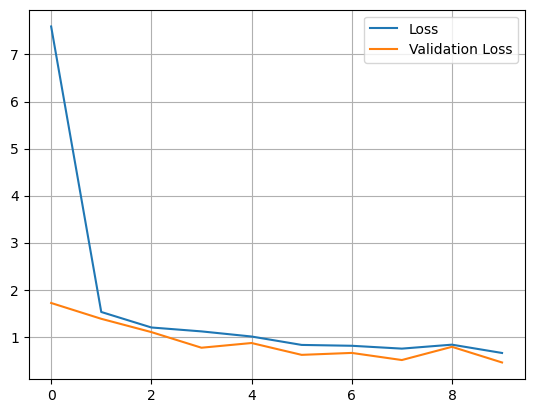

In [30]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [31]:
score = model.evaluate(test_dataset, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.5440949201583862
Test accuracy: 0.7978723645210266


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


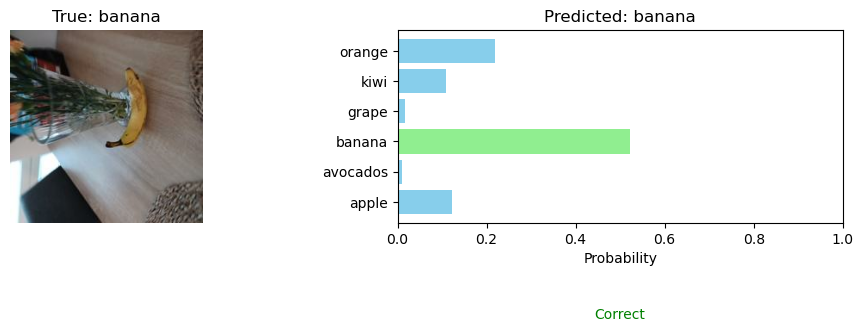

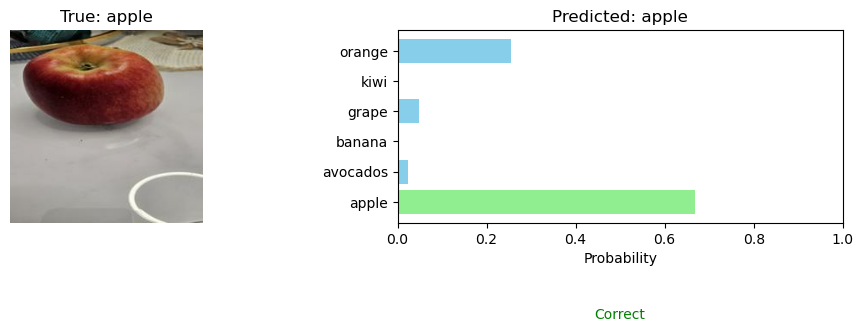

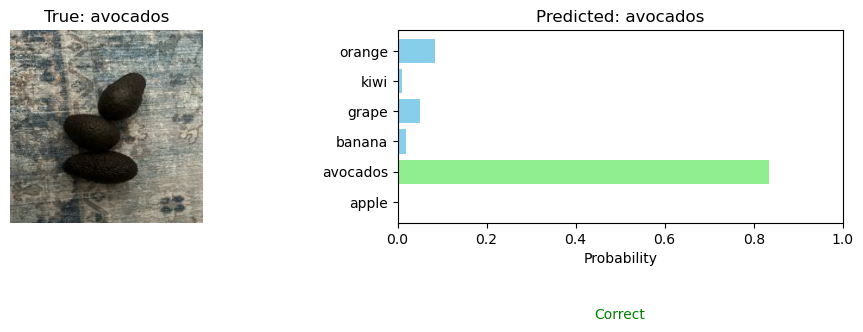

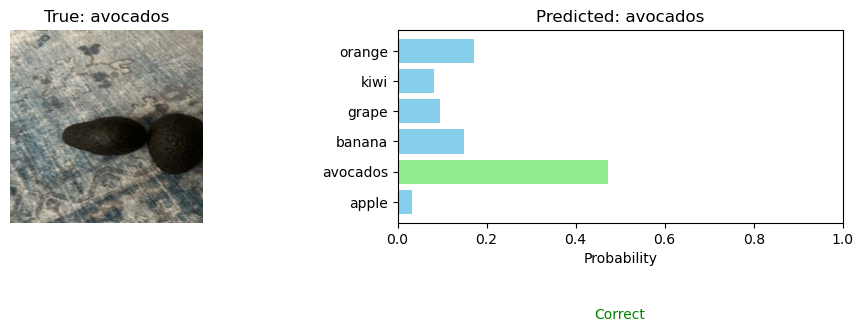

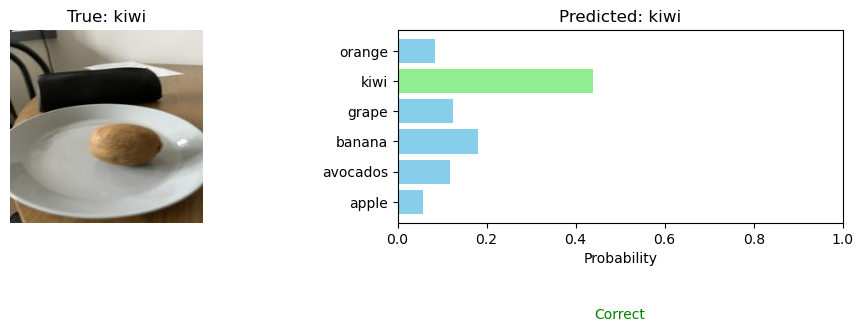

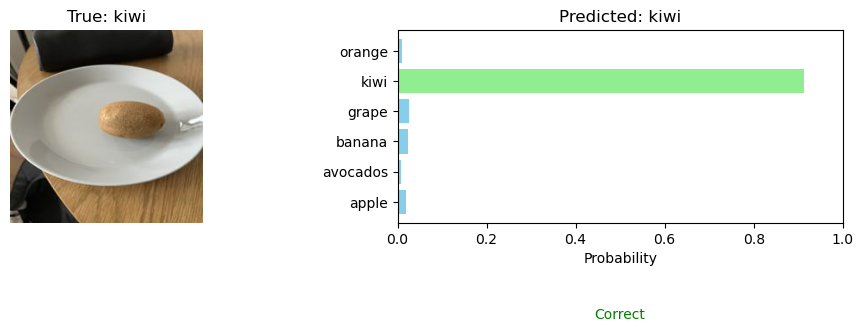

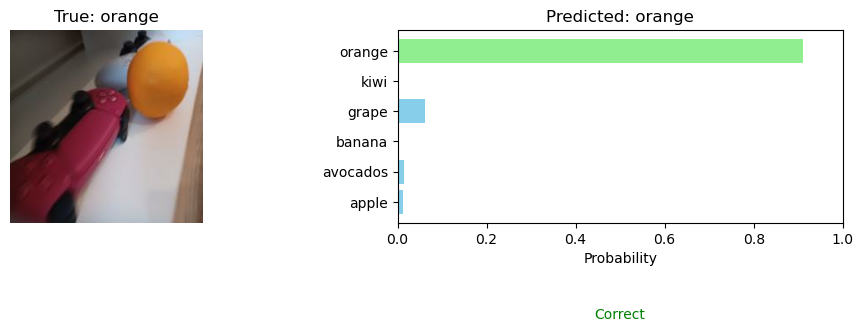

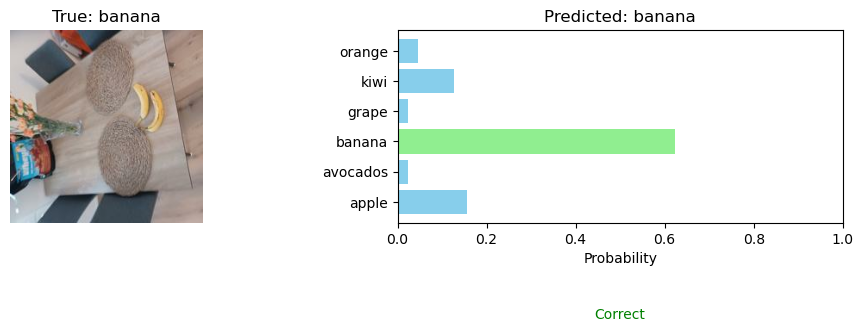

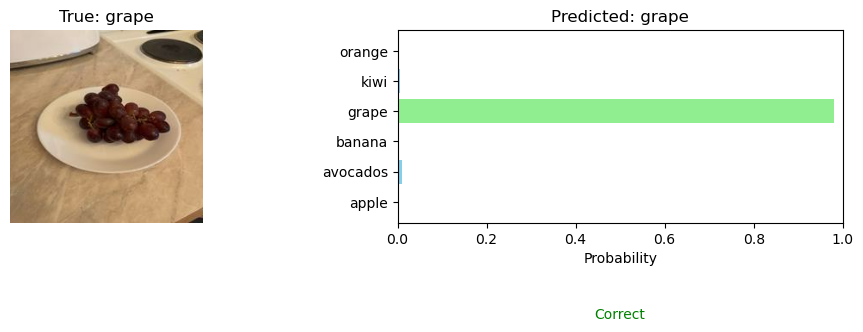

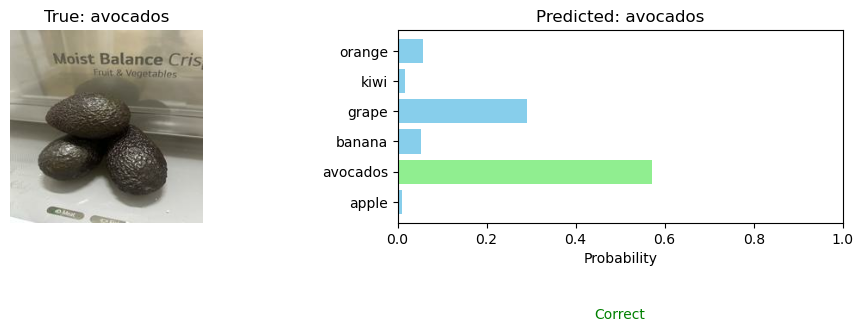

In [32]:
# Haetaan testidatasetista yksi batch
test_images, test_labels = next(iter(test_dataset.take(1)))

# Ennustetaan mallilla
predictions = model.predict(test_images)

# Muunnetaan one-hot-enkoodatut labelit kokonaisluvuiksi
true_labels = np.argmax(test_labels, axis=1)
predicted_labels = np.argmax(predictions, axis=1)

def plot_images(model):
    y_pred = []
    x_images = []
    y_true = []

    for images, labels in test_dataset:
        y_pred.extend(model.predict(images, batch_size=32))
        x_images.extend(images.numpy())
        y_true.extend(labels.numpy())

    y_pred = np.array(y_pred)
    y_true = np.array(y_true)
    x_images = np.array(x_images)

    num_samples = 10
    random_indices = random.sample(range(len(x_images)), num_samples)

    for i in random_indices:
        plt.figure(figsize=(10, 4))

        # Display image
        plt.subplot(1, 2, 1)
        plt.imshow((x_images[i] * 255).astype("uint8"))
        true_class = class_names[np.argmax(y_true[i])]
        plt.title(f"True: {true_class}")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        pred_prob = y_pred[i]
        predicted_class = class_names[np.argmax(pred_prob)]

        colors = ['lightgreen' if (class_names[idx] == true_class) else 'skyblue'
                  for idx in range(len(class_names))]

        plt.barh(class_names, pred_prob, color=colors)
        plt.xlabel('Probability')
        plt.title(f"Predicted: {predicted_class}")
        plt.xlim([0, 1])

        if predicted_class != true_class:
            plt.text(0.5, -0.5, "Incorrect", color='red',
                    ha='center', transform=plt.gca().transAxes)
        else:
            plt.text(0.5, -0.5, "Correct", color='green',
                    ha='center', transform=plt.gca().transAxes)

        plt.tight_layout()
        plt.show()

plot_images(model)

# Kuvantunnistus omilla kuvilla - VGG16 Assisted

In [33]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model  # Changed from Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, GlobalAveragePooling2D
import tensorflow as tf

vgg16_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

vgg16_base.trainable = False

x = vgg16_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(6, activation='softmax')(x)

model2 = Model(inputs=vgg16_base.input, outputs=predictions)

model2.compile(optimizer='adam',
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

history2 = model2.fit(train_dataset, validation_data=validation_dataset, epochs=10)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.3152 - loss: 1.8967 - val_accuracy: 0.3125 - val_loss: 1.4905
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.3818 - loss: 1.5388 - val_accuracy: 0.5312 - val_loss: 1.3544
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.5435 - loss: 1.2701 - val_accuracy: 0.6562 - val_loss: 1.0356
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5643 - loss: 1.1810 - val_accuracy: 0.7500 - val_loss: 0.9003
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.6800 - loss: 1.0066 - val_accuracy: 0.8125 - val_loss: 0.8171
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.7274 - loss: 0.8741 - val_accuracy: 0.7344 - val_loss: 0.8808
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.7776 - loss: 0.7608 - val_accuracy: 0.7656 - val_loss: 0.7733
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.7800 - loss: 0.7322 - val_accuracy: 0.9062 - 

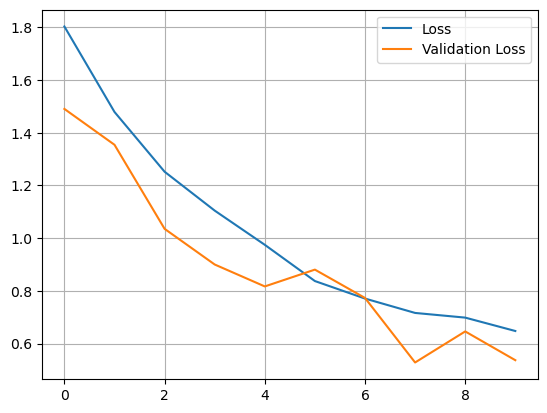

In [34]:
plt.plot(history2.history["loss"], label="Loss")
plt.plot(history2.history["val_loss"], label="Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [35]:
model2_test_score = model2.evaluate(test_dataset, verbose=0)
print('Test loss:', model2_test_score[0])
print('Test accuracy:', model2_test_score[1])

Test loss: 0.6217547059059143
Test accuracy: 0.8191489577293396


3/3 ━━━━━━━━━━━━━━━━━━━━ -0s 15ms/step - accuracy: 0.8563 - loss: 0.5087    


2025-04-01 12:20:37.166414: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:302: Filling up shuffle buffer (this may take a while): 213 of 256
2025-04-01 12:20:37.167193: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:482] Shuffle buffer filled.



Test Set Accuracy: 82.98%

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 599ms/step


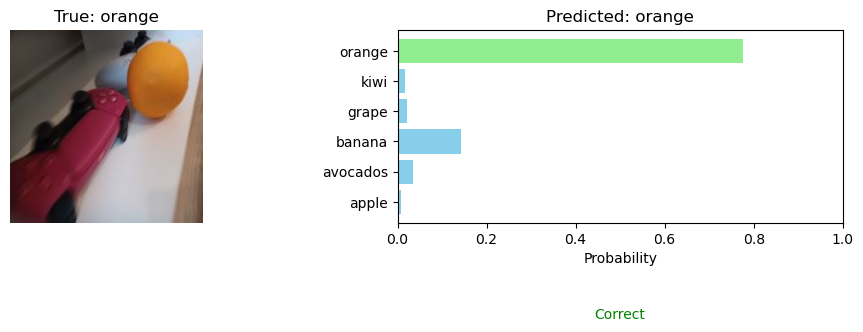

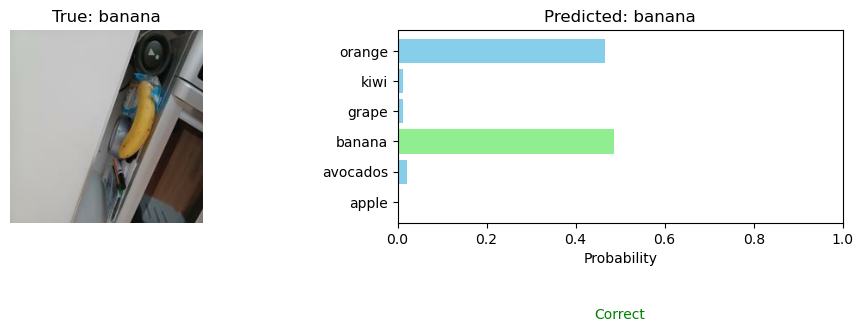

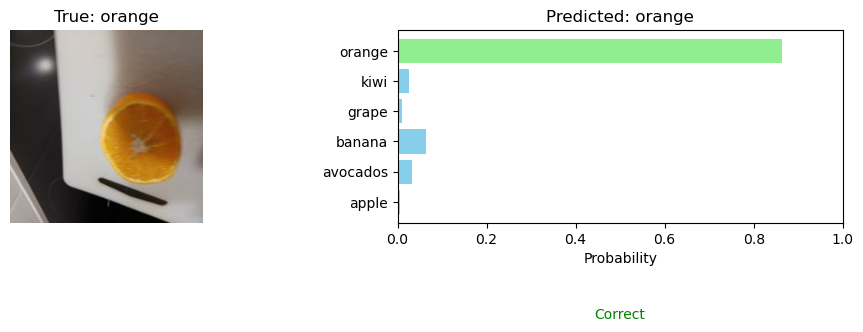

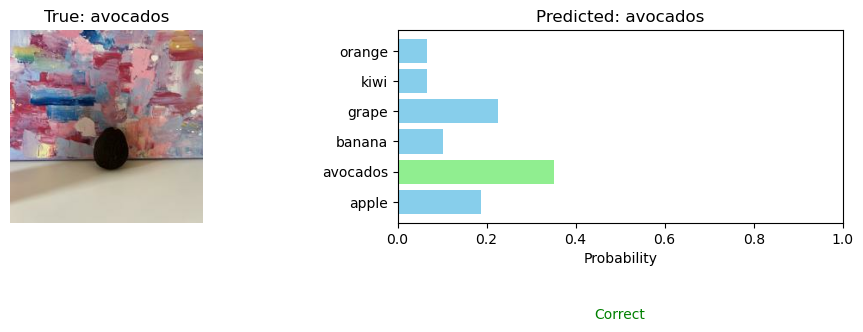

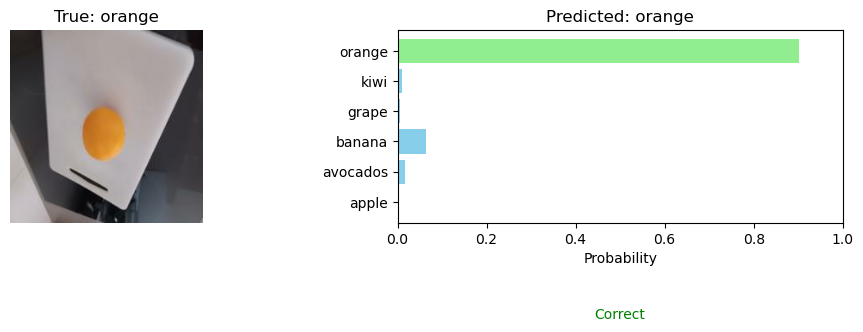

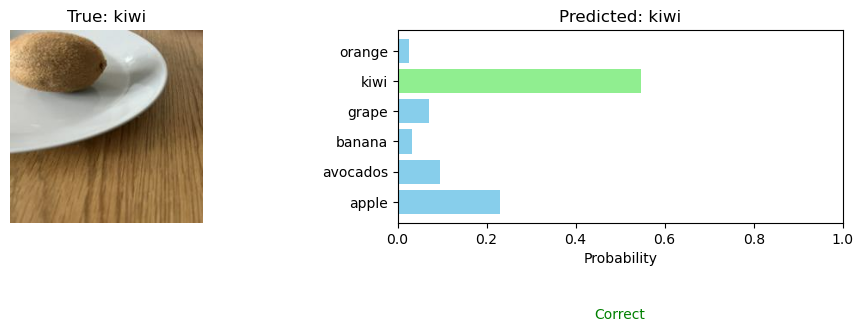

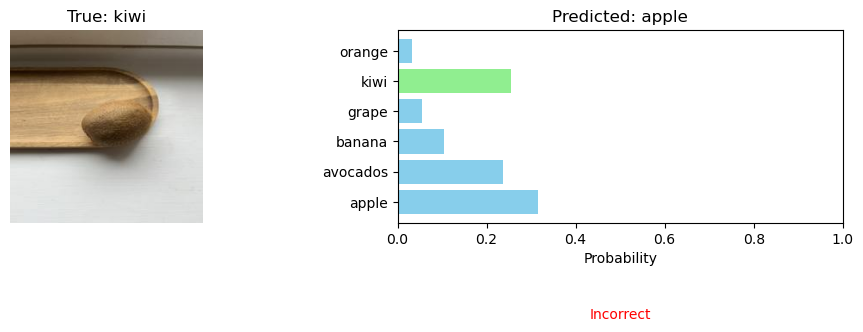

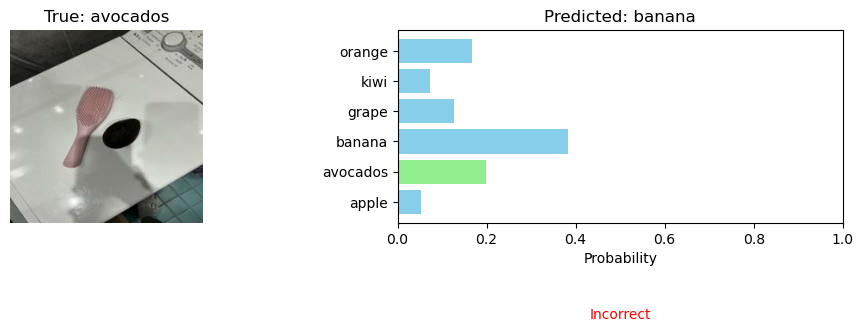

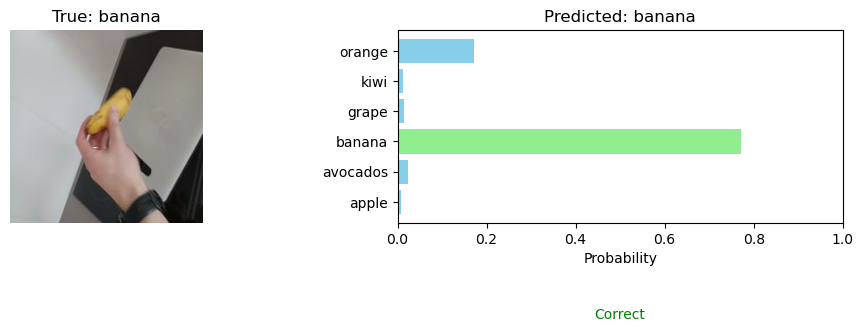

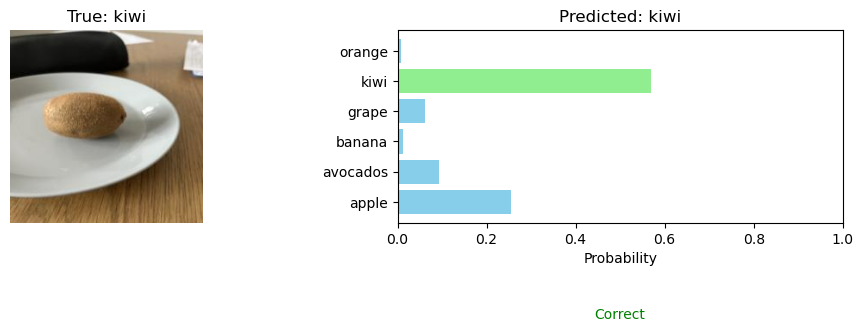

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import random

test_loss, test_acc = model.evaluate(test_dataset)
print(f"\nTest Set Accuracy: {test_acc*100:.2f}%\n")

plot_images(model2)